## Data Cleaning

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

raw=pd.read_excel('studentdataset_1.xlsx',sheet_name='dataset',header=None)
headers=raw.iloc[1].tolist()
df=raw.iloc[2:].copy()
df.columns=headers
df=df.reset_index(drop=True)

for col in ['CGPA','Maths Score','Physics Score','Programming Score','English Score','Study Hours/Day','Attendance (%)']:
    df[col]=pd.to_numeric(df[col],errors='coerce')

df.dropna(inplace=True)
df.head()


,Student ID,Name,Gender,Branch,Semester,Maths Score,Physics Score,Programming Score,English Score,CGPA,Study Hours/Day,Attendance (%)
0,S001,Aarav,Male,ECE,1,46.0,87.0,67.0,63.0,6.46,6.2,98.0
2,S003,Arjun,Male,CE,1,80.0,52.0,95.0,89.0,8.52,3.9,83.0
3,S004,Ananya,Female,EEE,2,96.0,95.0,50.0,96.0,8.97,5.9,76.0
8,S009,Kiran,Male,EEE,2,55.0,63.0,72.0,61.0,8.38,5.9,98.0
14,S015,Nikhil,Male,CSE,2,68.0,54.0,58.0,80.0,7.62,6.3,62.0


## Q1
To identify clusters of students who consistently study very little versus those who study a lot, plot study hours across all 60 student IDs in order. Which chart makes such clustering visible?

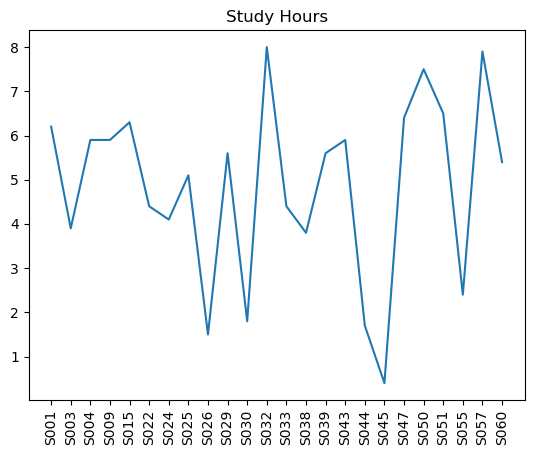

In [4]:
plt.plot(df['Student ID'], df['Study Hours/Day']); plt.xticks(rotation=90); plt.title('Study Hours'); plt.show()

## Q2
A data analyst wants to check whether CGPA values fluctuate randomly or follow a rising/falling pattern as student roll numbers increase from S001 to S060. Which chart is most appropriate for this sequential analysis?

In [ ]:
plt.plot(df['Student ID'], df['CGPA']); plt.xticks(rotation=90); plt.title('CGPA Trend'); plt.show()

## Q3
Before computing the class average CGPA, a statistician wants to know the shape of the CGPA distribution — is it bell-shaped, left-skewed, or right-skewed? Which chart reveals the distribution shape?

In [ ]:
plt.hist(df['CGPA'], bins=10); plt.title('CGPA Distribution'); plt.show()

## Q4
A Physics teacher suspects that students admitted later in the roll list (higher student IDs) scored lower in Physics due to reduced preparation time. Plot Physics scores from S001 to S060 to investigate. Which chart suits this?

In [5]:
plt.plot(df['Student ID'], df['Physics Score']); plt.xticks(rotation=90); plt.title('Physics Scores'); plt.show()

KeyError: 'Physics'

## Q5
A faculty member claims CSE students consistently outperform other branches in Maths. Which chart would best let you compare the average Maths score of all five branches side by side to verify or refute this claim?

In [ ]:
df.groupby('Branch')['Maths'].mean().plot(kind='bar'); plt.show()

## Q6
A student representative claims that Semester 2 students have more uneven attendance than Semester 1. Which chart would show the spread, median, and extreme attendance values for both semesters, side by side?

In [ ]:
df.boxplot(column='Attendance (%)', by='Semester'); plt.show()

## Q7
A counsellor notices that students with CGPA ≥ 8.5 seem to come from only a few branches. To present the branch composition of this high-achiever group to the principal, what chart would make the proportions immediately obvious?

In [ ]:
df[df['CGPA']>=8.5]['Branch'].value_counts().plot(kind='pie',autopct='%1.1f%%'); plt.show()

## Q8
The attendance committee wants to know whether most students are clustered near 100% attendance or if there is a long tail of low attenders. Which chart uncovers this pattern?

In [ ]:
plt.hist(df['Attendance (%)'], bins=10); plt.show()

## Q9
A gender-equity study wants to determine whether male and female students show comparable Maths performance, or whether one group has a wider spread of scores. Which chart is most informative?

In [ ]:
df.boxplot(column='Maths', by='Gender'); plt.show()

## Q10
A Maths teacher is unsure whether most students scored in a narrow band or whether scores are spread across the full range. Which chart would show the frequency of students in each score interval?

In [ ]:
plt.hist(df['Maths'], bins=10); plt.show()

## Q11
The placement cell needs to show, in a poster, what fraction of students fall in each CGPA slab (< 6, 6–7, 7–8, 8–9, ≥ 9) so companies can quickly judge the talent pool. Which chart is best suited?

In [ ]:
pd.cut(df['CGPA'],[0,6,7,8,9,10]).value_counts().plot(kind='pie',autopct='%1.1f%%'); plt.show()

## Q12
Before designing an integrated Maths–Physics module, a faculty wants to check if students who are strong in Maths are equally strong in Physics, or if the two subjects are independent. Which chart should be used?

In [ ]:
plt.scatter(df['Maths'],df['Physics']); plt.xlabel('Maths'); plt.ylabel('Physics'); plt.show()

## Q13
An English faculty member suspects that communication skills (English score) predict overall CGPA — students who write and communicate well tend to perform better overall. Test this using a chart.

In [ ]:
plt.scatter(df['English'],df['CGPA']); plt.show()

## Q14
A wellness study asks: do students who spend more time in class (higher attendance) also discipline themselves to study more at home? Plot attendance vs. study hours for all 60 students. Which chart fits?

In [ ]:
plt.scatter(df['Attendance (%)'],df['Study Hours/Day']); plt.show()

## Q15
The attendance office wants to detect if there is a progressive drop in attendance as the semester progresses, by tracking each student's attendance in registration order. Which chart captures this sequential behaviour?

In [ ]:
plt.plot(df['Student ID'],df['Attendance (%)']); plt.xticks(rotation=90); plt.show()

## Q16
Your HOD wants a single-glance summary of how the 60 students are split across CSE, ECE, ME, CE, and EEE for an accreditation report. Which chart conveys branch-wise enrolment as proportions most effectively?

In [ ]:
df['Branch'].value_counts().plot(kind='pie',autopct='%1.1f%%'); plt.show()

## Q17
A learning-behaviour researcher hypothesises: 'students who study more hours per day achieve higher CGPA.' Plot data for all 60 students to see if this hypothesis holds. Which chart type is needed?

In [ ]:
plt.scatter(df['Study Hours/Day'],df['CGPA']); plt.show()

## Q18
The time-table committee wants to know what proportion of students are in Semester 1 versus Semester 2 before scheduling common labs. Which chart best communicates this two-way split?

In [ ]:
df['Semester'].value_counts().plot(kind='pie',autopct='%1.1f%%'); plt.show()

## Q19
Three students appear to have unusually low Programming scores compared to their branch peers. Which chart would visually confirm these as outliers while also showing the typical performance range for each branch?

In [ ]:
df.boxplot(column='Programming', by='Branch'); plt.show()

## Q20
A placement coordinator believes Programming proficiency is the strongest predictor of CGPA. To validate this, plot each student's Programming score against their CGPA. Which chart is appropriate?

In [ ]:
plt.scatter(df['Programming'],df['CGPA']); plt.show()

## Q21
The HOD wants to know if enforcing higher attendance actually improves academic performance. Using each student as a data point with attendance on one axis and CGPA on the other, which chart reveals the relationship?

In [ ]:
plt.scatter(df['Attendance (%)'],df['CGPA']); plt.show()

## Q22
A programming instructor wants to see whether Programming scores improve, worsen, or stay erratic across sequential student IDs — possibly revealing a coaching effect. Which chart type should be used?

In [ ]:
plt.plot(df['Student ID'],df['Programming']); plt.xticks(rotation=90); plt.show()

## Q23
Before assigning project mentors, the department needs a count of how many students are enrolled in each branch to allocate mentors proportionally. Which chart makes these counts easiest to compare?

In [ ]:
df['Branch'].value_counts().plot(kind='bar'); plt.show()

## Q24
A gender-diversity initiative report requires a visual that shows whether the batch is close to a 50-50 split or heavily skewed toward one gender. What chart type should be used?

In [ ]:
df['Gender'].value_counts().plot(kind='pie',autopct='%1.1f%%'); plt.show()

## Q25
An academic committee suspects that CGPA variability differs greatly between branches — some branches may be very consistent while others are all over the place. Which chart simultaneously shows median, spread, and outliers for all five branches?

In [ ]:
df.boxplot(column='CGPA', by='Branch'); plt.show()

## Q26
Student welfare data suggests males and females may have different attendance habits. Which chart would most clearly show whether one gender group has a higher average attendance than the other?

In [ ]:
df.groupby('Gender')['Attendance (%)'].mean().plot(kind='bar'); plt.show()

## Q27
The academic council wants to identify whether any subject is being consistently under-performed across the class by comparing the class-wide average of Maths, Physics, Programming, and English. What chart lets you spot the weakest subject instantly?

In [ ]:
df[['Maths','Physics','Programming','English']].mean().plot(kind='bar'); plt.show()

## Q28
To assess overall branch performance, compute the average CGPA for CSE, ECE, ME, CE, and EEE. Which chart best ranks these five branches by academic performance?

In [ ]:
df.groupby('Branch')['CGPA'].mean().plot(kind='bar'); plt.show()

## Q29
An advisor suspects that students in branches with heavier lab workloads study fewer hours per day. To test this, compare average daily study hours across all five branches. Which chart is appropriate?

In [ ]:
df.groupby('Branch')['Study Hours/Day'].mean().plot(kind='bar'); plt.show()

## Q30
Before advising students on study habits, a counsellor wants to understand how study-hours per day are distributed: do most students study 3–5 hours, or is the spread uniform? Which chart answers this?

In [ ]:
plt.hist(df['Study Hours/Day'], bins=10); plt.show()